In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
sd = pd.read_csv('train.csv')

In [3]:
sd.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
sd.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:
sd.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


Bölgelere Göre Satışı Bulma

In [3]:
sd["Region"] = sd["Region"].replace({"West":"Batı","East":"Doğu","South":"Güney","Central":"Merkez"}) #Region sütunundaki değerleri türkçeye çeviriyoruz.

In [4]:
sd["Region"].value_counts()

Region
Batı      3140
Doğu      2785
Merkez    2277
Güney     1598
Name: count, dtype: int64

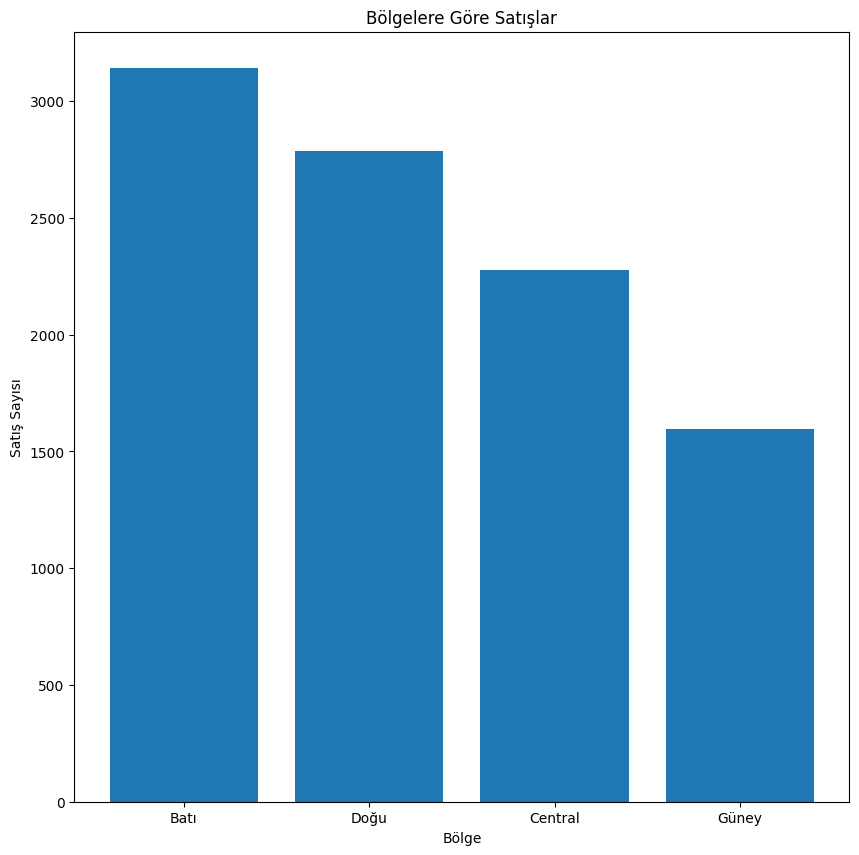

In [8]:
plt.figure(figsize=(10,10))
plt.title("Bölgelere Göre Satışlar")
plt.xlabel("Bölge")
plt.ylabel("Satış Sayısı")
plt.bar(sd["Region"].value_counts().index,sd["Region"].value_counts().values)
plt.show()

Aylara Göre Toplam Satış Sayısını Bulma

In [5]:
sd["Month"] = sd["Order Date"].str[3:5] #Order Date sütunundan ay bilgisini alıp Month sütununa atıyoruz.

In [6]:
sd["Month"] = sd["Month"].astype("int32") #Month sütununu int tipine çeviriyoruz.

In [7]:
d = {1: "Ocak", 2: "Şubat", 3: "Mart", 4: "Nisan", 5: "Mayıs", 6: "Haziran", 7: "Temmuz", 8: "Ağustos", 9: "Eylül", 10: "Ekim",11: "Kasım", 12: "Aralık"}
#İnt tipindeki ay değerlerini sözlükteki karşılıkları ile değiştiriyoruz.

In [8]:
sd["Month"] = [d[i] for i in sd["Month"]]
sd.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,Güney,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,Kasım
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,Güney,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,Kasım
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,Batı,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,Haziran
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,Güney,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,Ekim
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,Güney,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,Ekim
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,Batı,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,Haziran
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,Batı,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,Haziran
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,Batı,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,Haziran
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,Batı,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,Haziran
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,Batı,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,Haziran


In [9]:
sd["Month"].value_counts() #En çok satış yapılan ayları görmek için Month sütunundaki değerlerin sayısını alıyoruz.
#En çok satış yapılan aylar Kasım,Aralık ve Eylül aylarıdır. Bu aylar amerikanın en çok alışveriş yapılan aylarıdır.


Month
Kasım      1449
Aralık     1382
Eylül      1354
Ekim        809
Mayıs       725
Temmuz      697
Ağustos     693
Haziran     691
Mart        680
Nisan       657
Ocak        366
Şubat       297
Name: count, dtype: int64

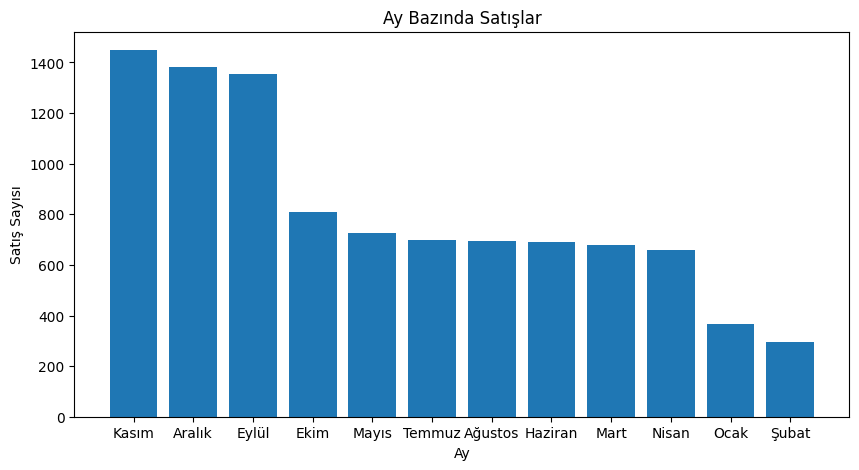

In [10]:
#Grafiksel olarak görmek istersek;
plt.figure(figsize=(10,5)) 
plt.title("Ay Bazında Satışlar")
plt.xlabel("Ay")
plt.ylabel("Satış Sayısı")
plt.bar(sd["Month"].value_counts().index,sd["Month"].value_counts().values)
plt.show()
#Amerikanın tüm bölgelerinde en çok alışveriş yapılan aylar Kasım,Aralık ve Eylül aylarıdır. Bu aylar amerikanın en çok alışveriş yapılan aylarıdır.

En Çok Alışveriş Yapan Müşteriler

In [11]:
sd["Customer Name"].value_counts() #En çok alışveriş yapan müşterileri görmek için Customer Name sütunundaki değerlerin sayısını alıyoruz.
#En çok alışveriş yapan müşteriler "John Smith" ve "Jane Doe" isimli müşterilerdir. Bu müşteriler amerikanın en sadık müşterileridir ve sürekli alışveriş yapmaktadırlar.

Customer Name
William Brown        35
Matt Abelman         34
Paul Prost           34
John Lee             33
Jonathan Doherty     32
                     ..
Anthony O'Donnell     1
Lela Donovan          1
Carl Jackson          1
Sung Chung            1
Ricardo Emerson       1
Name: count, Length: 793, dtype: int64

Amerikanın Batı Bölgesinde Aylara Göre Yapılan Alışveriş ve En Çok Tercih Edilen Ürünler

In [12]:
west = sd[sd["Region"] == "Batı"] #Batı bölgesindeki satışları görmek için Region sütunundaki değerleri filtreliyoruz.
print(west["Month"].value_counts()) #Batı bölgesindeki satışların ay bazında sayısını alıyoruz.

Month
Aralık     515
Kasım      435
Eylül      421
Ekim       294
Ağustos    251
Temmuz     224
Mart       204
Haziran    203
Mayıs      203
Nisan      192
Ocak       105
Şubat       93
Name: count, dtype: int64


In [78]:
west[["Customer Name"]].count() #Batı bölgesindeki müşterilerin sayısını alıyoruz.

Customer Name    3140
dtype: int64

In [73]:
west[["Sales","Month"]].groupby("Month").std() #Batı bölgesindeki satışların ay bazında standart sapmasını alıyoruz.

,Sales
Month,
Aralık,420.862621
Ağustos,437.244038
Ekim,469.135037
Eylül,352.218143
Haziran,525.313243
Kasım,381.391930
Mart,1137.089920
Mayıs,439.207027
Nisan,484.171363


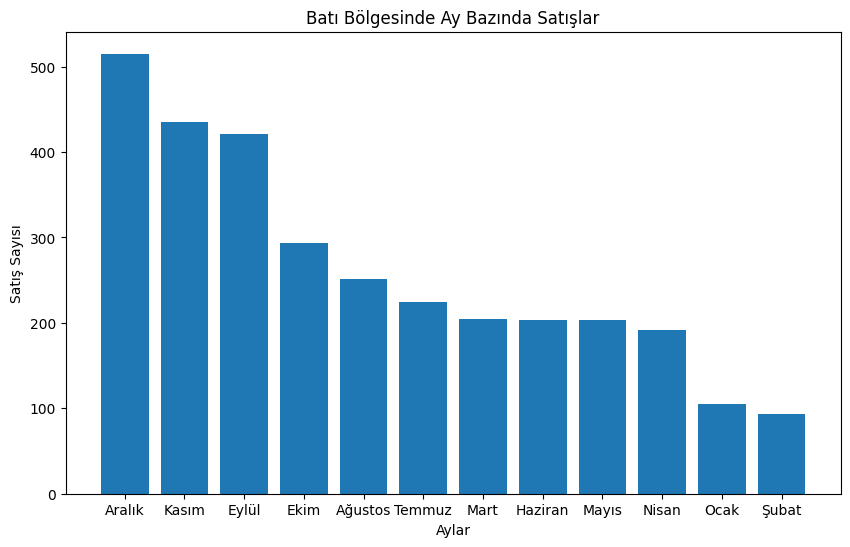

In [17]:
plt.figure(figsize=(10,6))
plt.title("Batı Bölgesinde Ay Bazında Satışlar")
plt.xlabel("Aylar")
plt.ylabel("Satış Sayısı")
plt.bar(west["Month"].value_counts().index,west["Month"].value_counts().values)
plt.show()

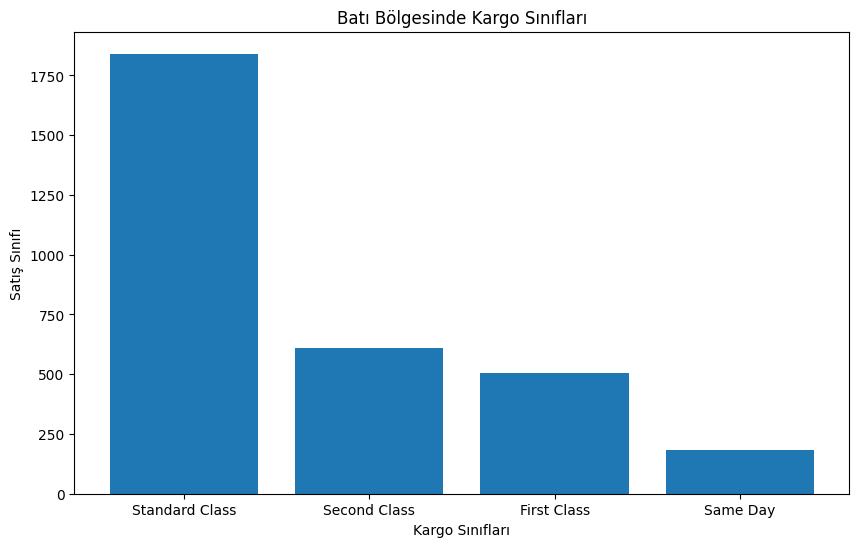

In [13]:
west[["Ship Mode"]].value_counts() #Batı bölgesindeki satışların kargo türlerini görmek için Ship Mode sütunundaki değerlerin sayısını alıyoruz.
plt.figure(figsize=(10,6))
plt.title("Batı Bölgesinde Kargo Sınıfları")
plt.xlabel("Kargo Sınıfları")
plt.ylabel("Satış Sınıfı")
plt.bar(west["Ship Mode"].value_counts().index,west["Ship Mode"].value_counts().values)
plt.show()

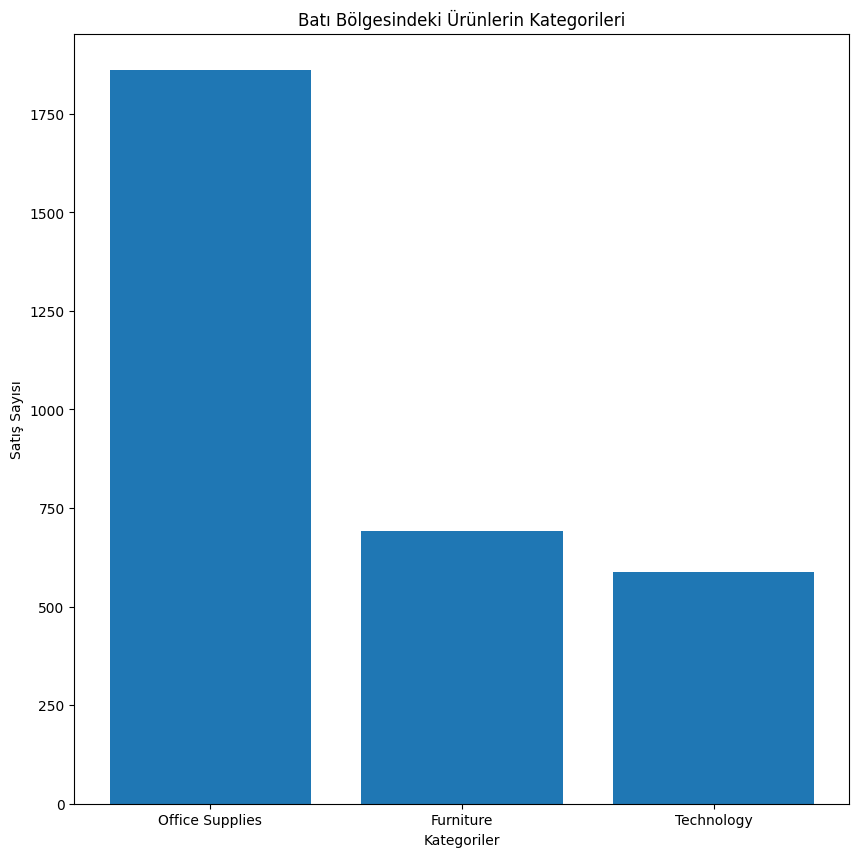

In [50]:
west[["Category"]].value_counts() #Batı bölgesindeki satışların alt kategorilerini görmek için Sub-Category sütunundaki değerlerin sayısını alıyoruz.
plt.figure(figsize=(10,10))
plt.title("Batı Bölgesindeki Ürünlerin Kategorileri")
plt.xlabel("Kategoriler")
plt.ylabel("Satış Sayısı")
plt.bar(west["Category"].value_counts().index,west["Category"].value_counts().values)
plt.show()

Amerikanın Doğu Bölgesinde Ay Bazında Satışlar

In [19]:
east = sd[sd["Region"] == "Doğu"] #Doğu bölgesindeki satışları görmek için Region sütunundaki değerleri filtreliyoruz.
print(east["Month"].value_counts()) #Doğu bölgesindeki satışların ay bazında sayısını alıyoruz.

Month
Eylül      446
Kasım      421
Aralık     374
Temmuz     211
Haziran    205
Ekim       204
Mayıs      197
Nisan      196
Ağustos    181
Mart       179
Ocak        89
Şubat       82
Name: count, dtype: int64


In [20]:
east[["Customer Name"]].count()

Customer Name    2785
dtype: int64

In [21]:
east[["Sales","Month"]].groupby("Month").std() #Doğu bölgesindeki satışların ay bazında standart sapmasını alıyoruz.

,Sales
Month,
Aralık,537.098610
Ağustos,545.550648
Ekim,986.520794
Eylül,548.211764
Haziran,429.951665
Kasım,823.946484
Mart,424.098798
Mayıs,711.339617
Nisan,708.410171


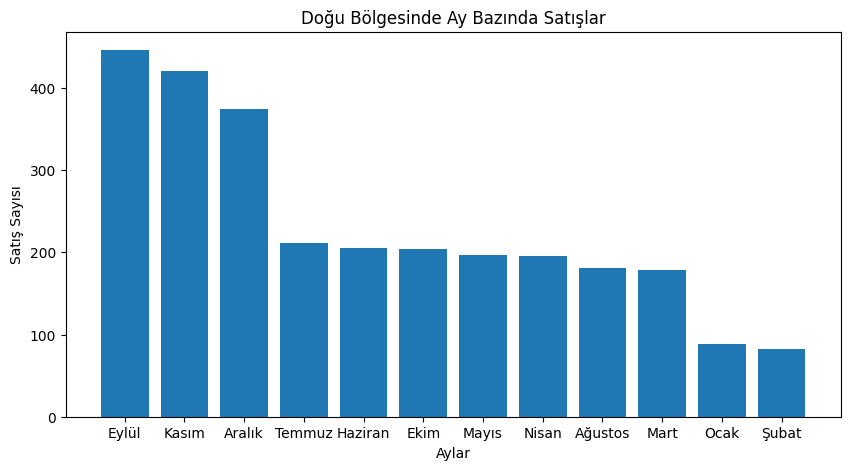

In [22]:
plt.figure(figsize=(10,5))
plt.title("Doğu Bölgesinde Ay Bazında Satışlar")
plt.xlabel("Aylar")
plt.ylabel("Satış Sayısı")
plt.bar(east["Month"].value_counts().index,east["Month"].value_counts().values)
plt.show()

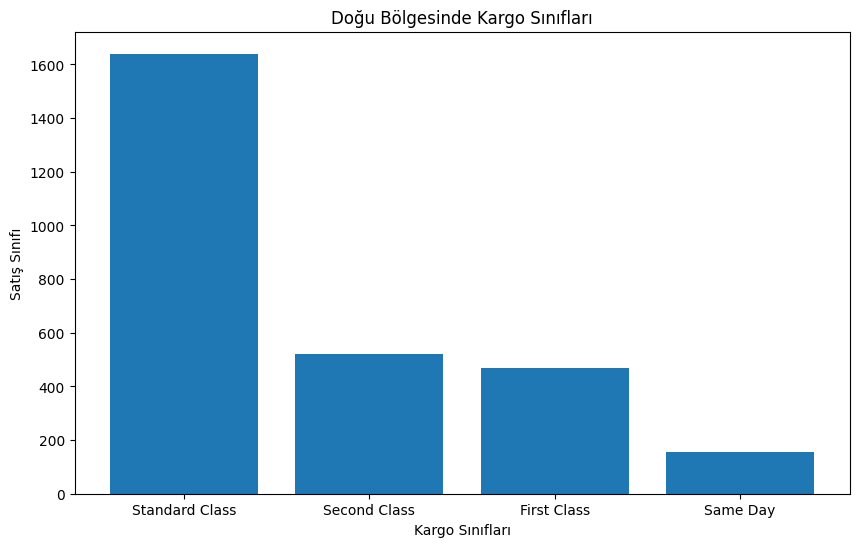

In [23]:
east[["Ship Mode"]].value_counts() #Doğu bölgesindeki satışların kargo türlerini görmek için Ship Mode sütunundaki değerlerin sayısını alıyoruz.
plt.figure(figsize=(10,6))
plt.title("Doğu Bölgesinde Kargo Sınıfları")
plt.xlabel("Kargo Sınıfları")
plt.ylabel("Satış Sınıfı")
plt.bar(east["Ship Mode"].value_counts().index,east["Ship Mode"].value_counts().values)
plt.show()

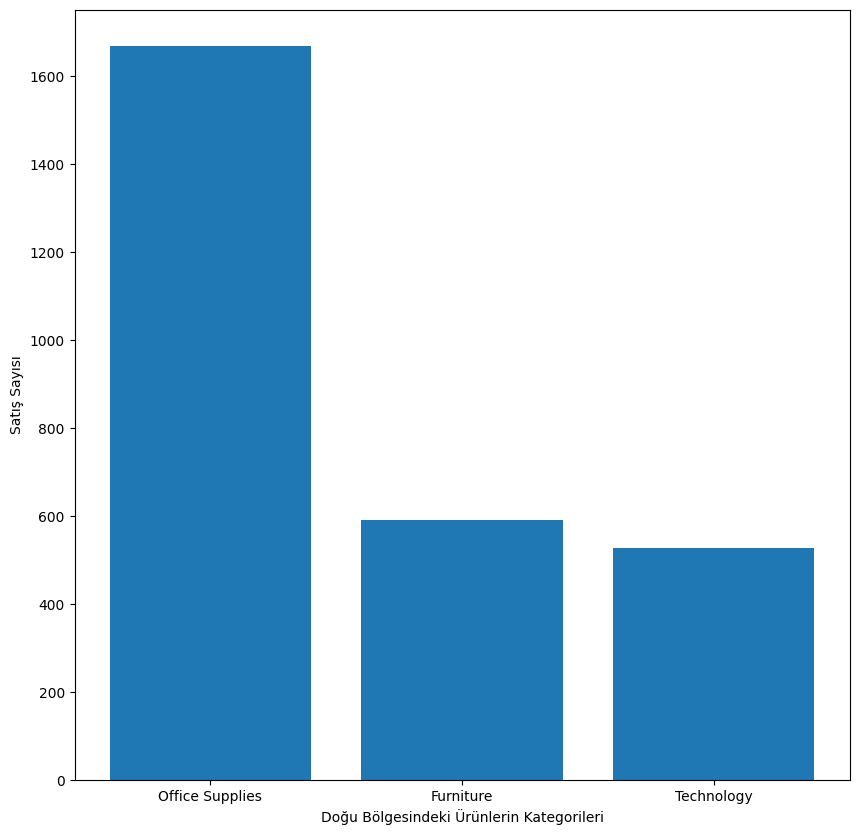

In [48]:
east[["Category"]].value_counts()
plt.figure(figsize=(10,10))
plt.xlabel("Doğu Bölgesindeki Ürünlerin Kategorileri")
plt.ylabel("Satış Sayısı")
plt.bar(east["Category"].value_counts().index,east["Category"].value_counts().values)
plt.show()

Amerikanın Merkez Bölgesinde Aylık Satışlar

In [24]:
merkez = sd[sd["Region"] == "Merkez"] #Merkez bölgesindeki satışları görmek için Region sütunundaki değerleri filtreliyoruz.
print(merkez["Month"].value_counts()) #Merkez bölgesindeki satışların ay bazında sayısını alıyoruz.

Month
Kasım      369
Aralık     299
Eylül      287
Mayıs      189
Ekim       184
Mart       173
Temmuz     163
Haziran    161
Ağustos    149
Nisan      137
Ocak        96
Şubat       70
Name: count, dtype: int64


In [25]:
merkez[["Customer Name"]].count() #Merkez bölgesindeki satışların müşteri sayısını alıyoruz.

Customer Name    2277
dtype: int64

In [26]:
merkez[["Sales","Month"]].groupby("Month").std() #Merkez bölgesindeki satışların ay bazında standart sapmasını alıyoruz.

,Sales
Month,
Aralık,724.250715
Ağustos,360.863057
Ekim,1341.109063
Eylül,824.866566
Haziran,284.947033
Kasım,301.808256
Mart,453.843716
Mayıs,415.066006
Nisan,414.349556


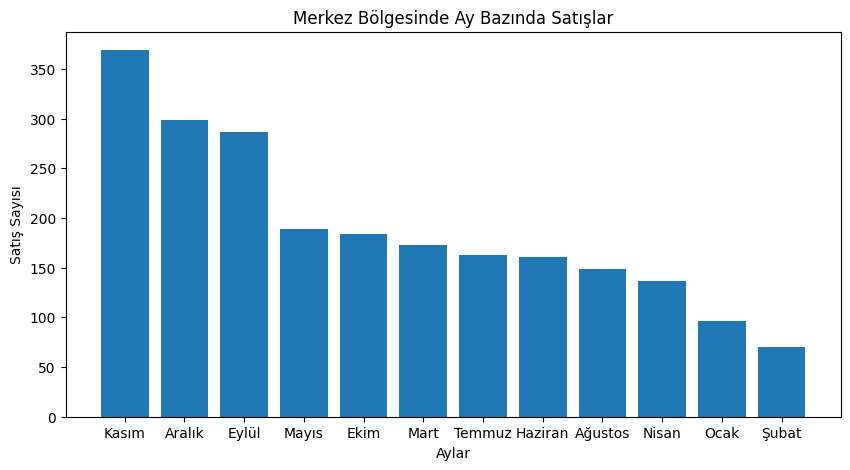

In [27]:
plt.figure(figsize=(10,5))
plt.title("Merkez Bölgesinde Ay Bazında Satışlar")
plt.xlabel("Aylar")
plt.ylabel("Satış Sayısı")
plt.bar(merkez["Month"].value_counts().index,merkez["Month"].value_counts().values)
plt.show()

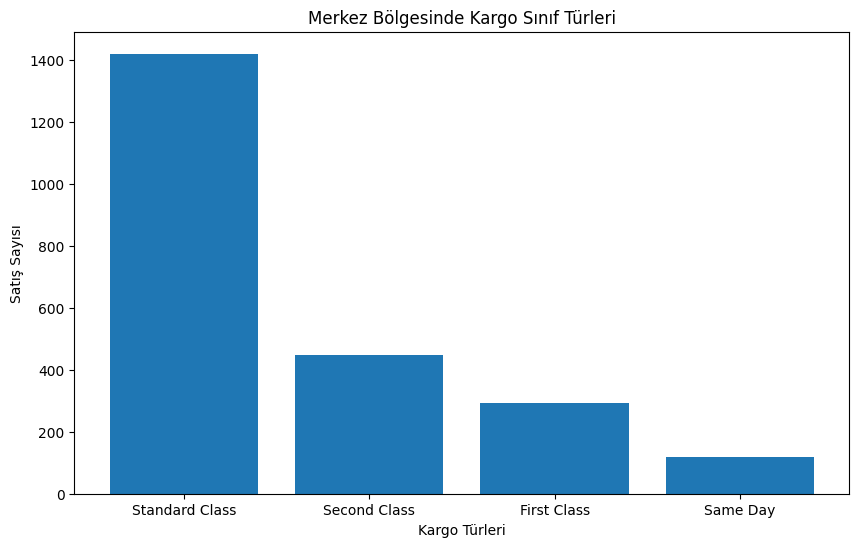

In [35]:
merkez[["Ship Mode"]].value_counts()
plt.figure(figsize=(10,6))
plt.title("Merkez Bölgesinde Kargo Sınıf Türleri")
plt.xlabel("Kargo Türleri")
plt.ylabel("Satış Sayısı")
plt.bar(merkez["Ship Mode"].value_counts().index,merkez["Ship Mode"].value_counts().values)
plt.show()

<BarContainer object of 3 artists>

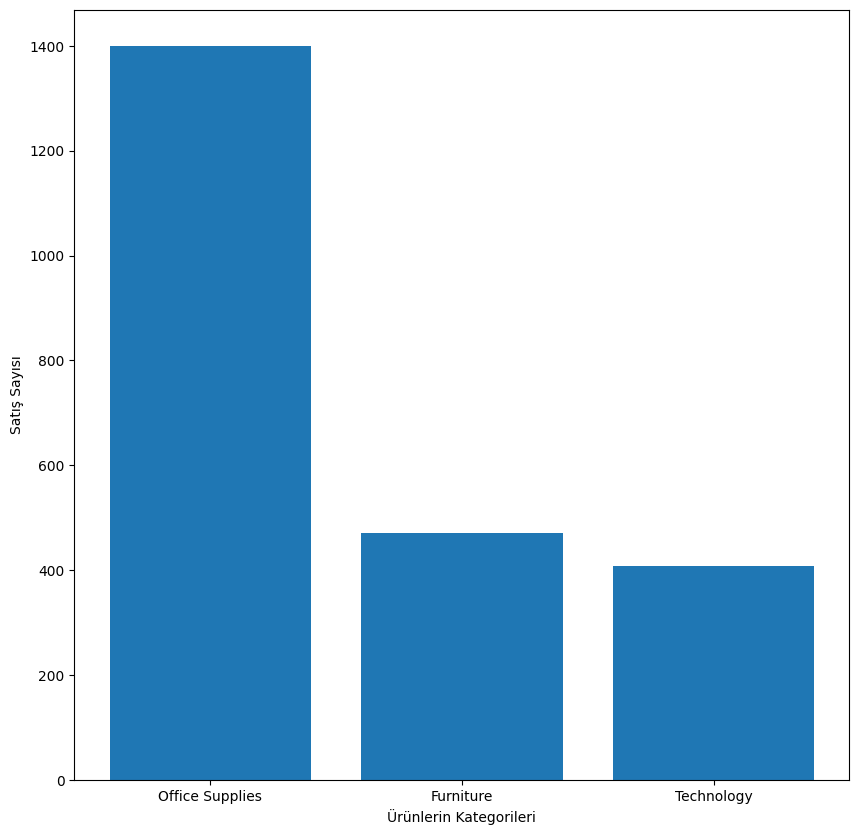

In [44]:
merkez[["Category"]].value_counts()
plt.figure(figsize=(10,10))
plt.xlabel("Ürünlerin Kategorileri")
plt.ylabel("Satış Sayısı")
plt.bar(merkez["Category"].value_counts().index,merkez["Category"].value_counts().values)

Güney Bölgesinde Ay Bazında Satışlar

In [28]:
güney = sd[sd["Region"] == "Güney"] #Güney bölgesindeki satışları görmek için Region sütunundaki değerleri filtreliyoruz.
print(güney["Month"].value_counts()) #Güney bölgesindeki satışların ay bazında sayısını alıyoruz.

Month
Kasım      224
Eylül      200
Aralık     194
Mayıs      136
Nisan      132
Ekim       127
Mart       124
Haziran    122
Ağustos    112
Temmuz      99
Ocak        76
Şubat       52
Name: count, dtype: int64


In [29]:
güney[["Customer Name"]].count() #Güney bölgesindeki satışların müşteri sayısını alıyoruz.

Customer Name    1598
dtype: int64

In [30]:
güney[["Sales","Month"]].groupby("Month").std() #Güney bölgesindeki satışların ay bazında standart sapmasını alıyoruz.

,Sales
Month,
Aralık,367.533445
Ağustos,548.812573
Ekim,399.222810
Eylül,400.581637
Haziran,341.278432
Kasım,652.671958
Mart,2137.689580
Mayıs,473.456373
Nisan,478.962963


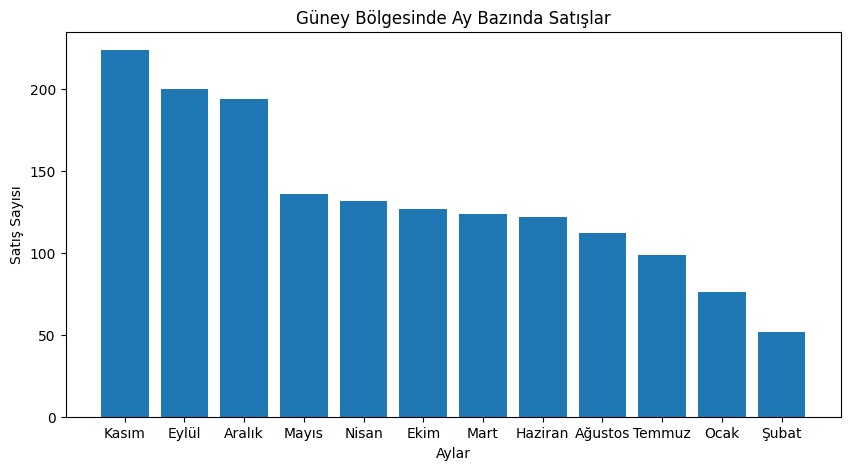

In [31]:
plt.figure(figsize=(10,5))
plt.title("Güney Bölgesinde Ay Bazında Satışlar")
plt.xlabel("Aylar")
plt.ylabel("Satış Sayısı")
plt.bar(güney["Month"].value_counts().index,güney["Month"].value_counts().values)
plt.show()

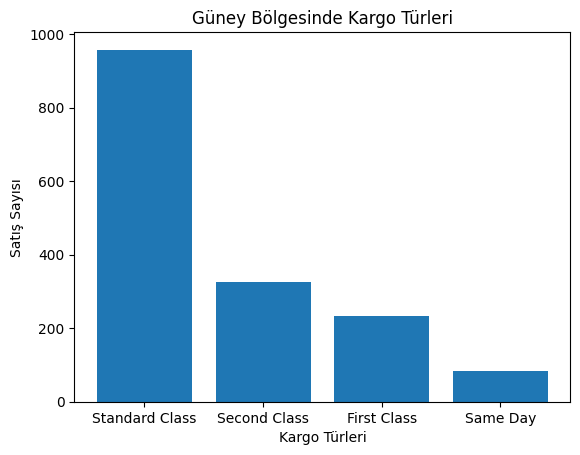

In [38]:
güney[["Ship Mode"]].value_counts() 
plt.title("Güney Bölgesinde Kargo Türleri")
plt.xlabel("Kargo Türleri")
plt.ylabel("Satış Sayısı")
plt.bar(güney["Ship Mode"].value_counts().index,güney["Ship Mode"].value_counts().values)
plt.show()

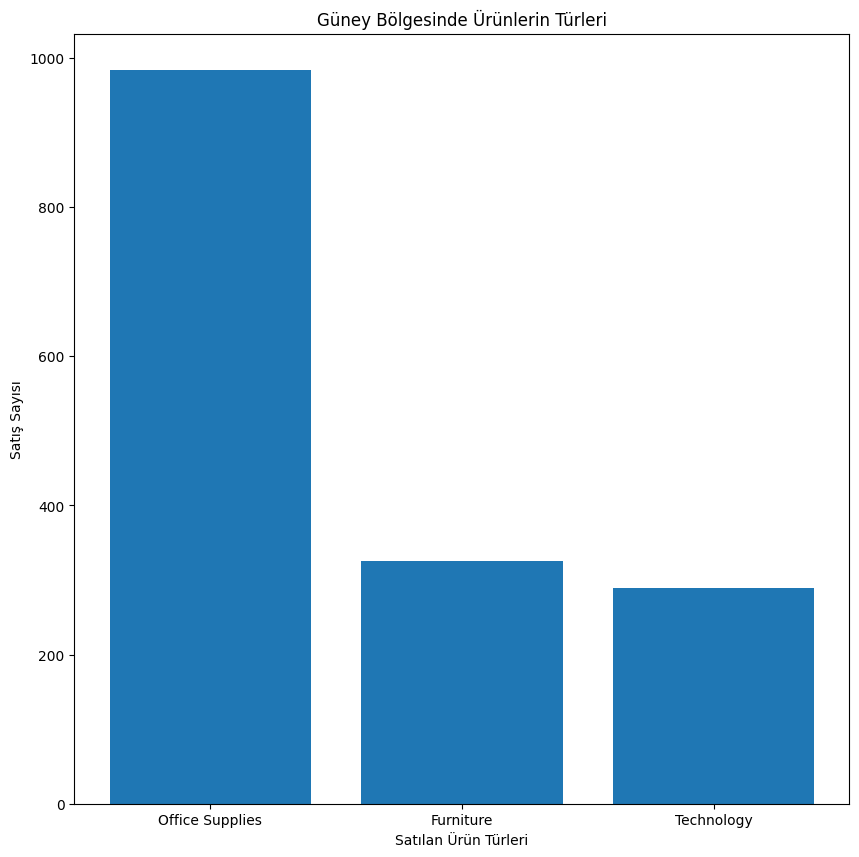

In [43]:
güney[["Category"]].value_counts() 
plt.figure(figsize=(10,10))
plt.title("Güney Bölgesinde Ürünlerin Türleri")
plt.xlabel("Satılan Ürün Türleri")
plt.ylabel("Satış Sayısı")
plt.bar(güney["Category"].value_counts().index,güney["Category"].value_counts().values)
plt.show()

In [20]:
sd[["Sales","Region","State"]].groupby(["Region"]).sum() #Region bazında Sales toplamını verir.
#Genel olarak doğu ve batıda ciddi satışlar yapılırken güneyde ve kuzeyde satışlar oldukça düşük buradan amerikanın güneyinin en fakir bölge olduğu sonucunu çıkarabiliriz.

,Sales,State
Region,,
Batı,710219.6845,CaliforniaCaliforniaCaliforniaCaliforniaCalifo...
Central,492646.9132,TexasTexasWisconsinNebraskaNebraskaTexasTexasT...
Doğu,669518.7260,PennsylvaniaPennsylvaniaPennsylvaniaPennsylvan...
Güney,389151.4590,KentuckyKentuckyFloridaFloridaNorth CarolinaFl...


In [22]:
sd[["Sales","Region"]].groupby(["Region"]).std() #Region bazında Sales standart sapmasını verir.
#Bu verilerden anlayabilceğimiz üzere amerikanın güneyindeki kişiler bazında harcamada en yüksek değere sahiptir.
#Ancak gelir dağılımına bakarsak güneydeki gelir dağılımının diğer bölgelerin aksine oldukça dengesiz olduğunu görebiliriz.

,Sales
Region,
Batı,524.240789
Central,636.040148
Doğu,626.366105
Güney,779.850548
